# Preparing Z-Orderings

Recall
$$
H = \frac{\hbar \Omega}{2} \sum_i  X_i - \hbar \delta \sum_i  N_i + \sum_{i<j} \frac{C_6}{r_{ij}^6}N_i N_j 
$$
Suppose $\Omega=0$, and we consider a $1D$ with lattice spacing $a$ ($r_i=ia$)
$$
H = - \hbar \delta \sum_i  N_i + \frac{C_6}{a^6} \sum_{i<j} \frac{N_i N_j}{(i-j)^6} 
$$

For $\delta \le 0$ the Ground state contains zero excitations, thus we consider only $\delta>0$.

Note that in this case the Hamiltonian is diagonal in the eigenvalue basis and hence it is easy to compute the phase diagram.

In [1]:
import qse 
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
c6 = 5420158.53  # (rad/µs)(µm)**6

n_atoms = 7
basis = np.array(qse.magnetic.get_basis(n_atoms), dtype=int)
detuning = -2 * np.pi * basis.sum(1)

interaction_term = np.zeros(basis.shape[0])

for c, b in enumerate(basis):
    for i in range(n_atoms-1):
        for j in range(i+1, n_atoms):
            if b[i] and b[j]:
                interaction_term[c] += 1. / (i-j)**6

interaction_term *= c6

In [4]:
spacings = np.linspace(2, 20, 140)
energies = np.zeros_like(spacings)
phases = np.zeros_like(spacings, dtype=int)

for i, a in enumerate(spacings):
    energy = detuning + interaction_term / a**6 
    energies[i] = np.min(energy)
    phases[i] = np.argmin(energy)

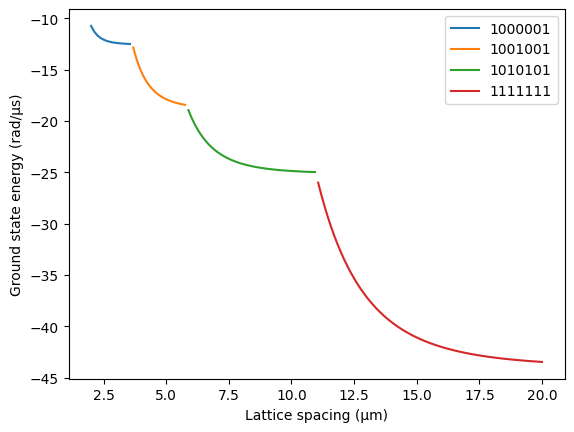

In [5]:
for s in np.unique(phases):
    inds = np.where(phases == s)[0]
    plt.plot(spacings[inds], energies[inds], label="".join(str(b) for b in basis[s]))

plt.xlabel("Lattice spacing (µm)")
plt.ylabel("Ground state energy (rad/µs)")

plt.legend()

plt.show()

In [6]:
qbits = qse.lattices.chain(4.2, n_atoms)

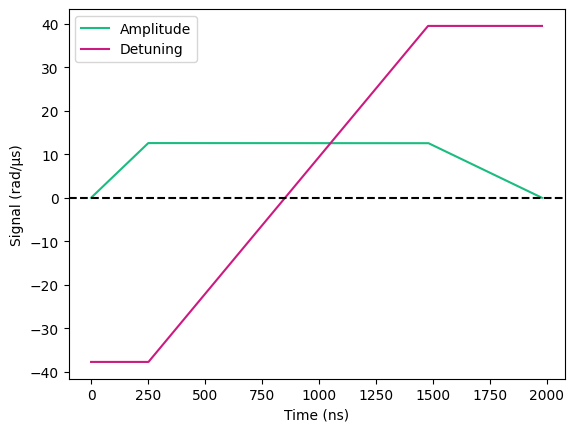

In [ ]:
omega_max = 2.0 * 2 * np.pi  # rad/µs

delta_0 = -3 * omega_max  # rad/µs
delta_f = (2 * np.pi)**2  # rad/µs

t_rise = 252  # ns
t_fall = 500  # ns
t_sweep = int((delta_f - delta_0) / (2 * np.pi * 10) * 1000)  # ns

amplitude = qse.Signals()
amplitude += qse.Signal(np.linspace(0.0, omega_max, t_rise))
amplitude += qse.Signal([omega_max], t_sweep)
amplitude += qse.Signal(np.linspace(omega_max, 0.0, t_fall))

detuning = qse.Signals()
detuning += qse.Signal([delta_0], t_rise)
detuning += qse.Signal(np.linspace(delta_0, delta_f, t_sweep))
detuning += qse.Signal([delta_f], t_fall)

# Check both signals have the same duration
assert amplitude.duration == detuning.duration

fig = qse.vis.draw_amp_and_det(amplitude, detuning, "ns", "rad/µs")

In [8]:
pcalc = qse.calc.Pulser(qbits=qbits, amplitude=amplitude, detuning=detuning, wtimes=False)
pcalc.build_sequence()
pcalc.calculate()

probs = (np.conj(pcalc.statevector) * pcalc.statevector).real

10.0%. Run time:   0.02s. Est. time left: 00:00:00:00
20.0%. Run time:   0.06s. Est. time left: 00:00:00:00
30.0%. Run time:   0.10s. Est. time left: 00:00:00:00
40.0%. Run time:   0.16s. Est. time left: 00:00:00:00


/Users/jnelson/qse/qse/qbits.py:1200: UserWarning: 1D system passed, adding a y axis.
  warnings.warn("1D system passed, adding a y axis.")


50.0%. Run time:   0.21s. Est. time left: 00:00:00:00
60.0%. Run time:   0.26s. Est. time left: 00:00:00:00
70.0%. Run time:   0.32s. Est. time left: 00:00:00:00
80.0%. Run time:   0.37s. Est. time left: 00:00:00:00
90.0%. Run time:   0.43s. Est. time left: 00:00:00:00
100.0%. Run time:   0.49s. Est. time left: 00:00:00:00
Total run time:   0.49s


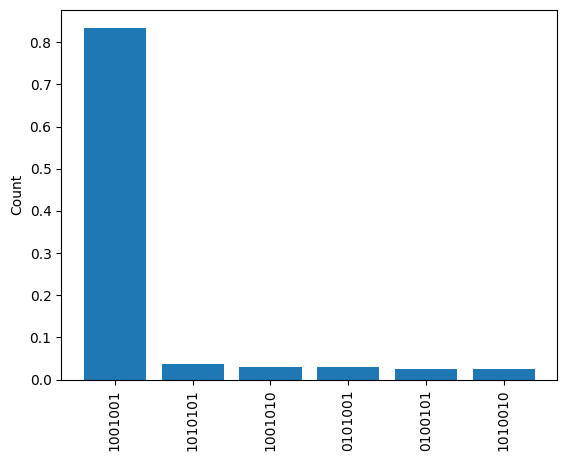

In [9]:
p_dict = {"".join(str(s) for s in basis[i]): p for i,p in enumerate(probs)}
p_dict = {w: p_dict[w] for w in sorted(p_dict, key=p_dict.get, reverse=True)}

fig = qse.vis.bar(p_dict, cutoff=0.01)

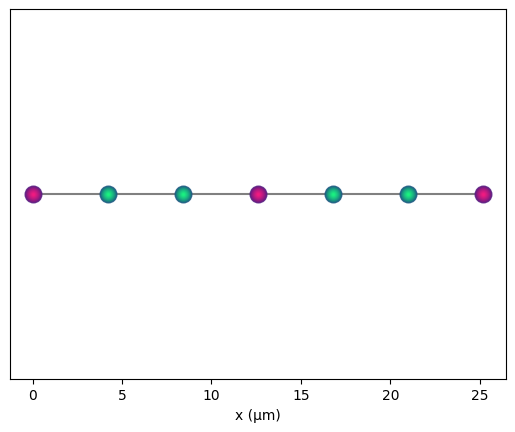

In [10]:
qbits.draw(radius="nearest", units="µm", colouring=basis[np.argmax(probs)])